# 3 - LeNet

In this notebook, we will be implementing a modified version of [LeNet-5](http://yann.lecun.com/exdb/lenet/), a neural network model that uses convolutional neural network (CNN) layers and was designed for [classifying handwritten characters](http://yann.lecun.com/exdb/publis/pdf/lecun-01a.pdf). CNNs are ubiquitous in modern computer vision. Almost every neural network model for computer vision contains many CNN layers, also referred to as convolutional layers, thus they're an important concept to understand. We will explain how they work when we implement the model.

The image below shows the architecture of LeNet-5. It consists of two convolutional layers, each followed by a subsampling layer, and then three fully connected linear layers.

<!-- ![](https://github.com/bentrevett/pytorch-image-classification/blob/master/assets/lenet5.png?raw=1) -->

Like the previous notebook, we'll implement LeNet, measure its performance on the MNIST dataset, and then have a short look into seeing what the model has learned.

Most of this notebook will be similar to the previous one, thus we will skim over code that has been shown before. We can look at the previous notebook for a refresher if needed.

### Data Processing

As always, we'll import the modules we need...

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

import torchvision.transforms as transforms
import torchvision.datasets as datasets

from sklearn import decomposition
from sklearn import manifold
from tqdm.notebook import tqdm, trange
import matplotlib.pyplot as plt
import numpy as np

import copy
import random
import time

...set the random seed for reproducability...

In [2]:
SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

...and calculate the mean and standard deviation across our training set so we can normalize our data.

In [3]:
ROOT = './data'

train_data = datasets.MNIST(root=ROOT,
                            train=True,
                            download=True)

mean = train_data.data.float().mean() / 255
std = train_data.data.float().std() / 255

print(f'Calculated mean: {mean}')
print(f'Calculated std: {std}')

Calculated mean: 0.13066047430038452
Calculated std: 0.30810779333114624


Then, we'll define our train and test transforms...

In [4]:
train_transforms = transforms.Compose([
                            transforms.RandomRotation(5, fill=(0,)),
                            transforms.RandomCrop(28, padding=2),
                            transforms.ToTensor(),
                            transforms.Normalize(mean=[mean], std=[std])
                                      ])

test_transforms = transforms.Compose([
                           transforms.ToTensor(),
                           transforms.Normalize(mean=[mean], std=[std])
                                     ])

...load our train and test data...

In [5]:
train_data = datasets.MNIST(root=ROOT,
                            train=True,
                            download=True,
                            transform=train_transforms)

test_data = datasets.MNIST(root=ROOT,
                           train=False,
                           download=True,
                           transform=test_transforms)

...and create a validation set from 10% of our training data.

Remember that the validation set should always be taken from the training data, and never the test data.

In [6]:
VALID_RATIO = 0.9

n_train_examples = int(len(train_data) * VALID_RATIO)
n_valid_examples = len(train_data) - n_train_examples

train_data, valid_data = data.random_split(train_data,
                                           [n_train_examples, n_valid_examples])

The validation set is using the same transforms as the training set, as it was created from it. As we want our validation set to remain static, to better resemble our test set, we replace these with the test transforms - remembering to `deepcopy` the validation set.

In [7]:
valid_data = copy.deepcopy(valid_data)
valid_data.dataset.transform = test_transforms

We'll print out the number of examples in the training/validation/test sets to ensure everything has been loaded correctly.

In [8]:
print(f'Number of training examples: {len(train_data)}')
print(f'Number of validation examples: {len(valid_data)}')
print(f'Number of testing examples: {len(test_data)}')

Number of training examples: 54000
Number of validation examples: 6000
Number of testing examples: 10000


The final part of the data processing stage is to create our dataloaders/iterators.

Again, we use a batch size of 64 and only shuffle the training data each epoch.

In [9]:
BATCH_SIZE = 64

train_iterator = data.DataLoader(train_data,
                                 shuffle=True,
                                 batch_size=BATCH_SIZE)

valid_iterator = data.DataLoader(valid_data,
                                 batch_size=BATCH_SIZE)

test_iterator = data.DataLoader(test_data,
                                batch_size=BATCH_SIZE)

Similarly to convolutional layers, if the input image has more than one channel, the filter has a depth equal to the number of channels. Thus, if we did a max pool with a 5x5x6 filter (height and width of 5 and depth of 6), the output at each pixel would be the maximum value of all 150 pixels covered by the filter.

### Defining the Model

Now we've gone through all the concepts, we can implement our model.


Our actual implementation is going to slightly differ from the actual LeNet architecture, as it was built to handle 32x32 images, whereas the MNIST dataset consists of 28x28 images. We're also not going to use the Gaussian connections at the end, instead we'll just use a standard linear layer.

The first layer in our model is a convolutional layer with 6 filters (PyTorch calls them `out_channels`) and a kernel size of 5. This turns our `[1, 28, 28]` image into `[6, 24, 24]`. We then downsample our image with a max pooling layer that has a filter size of 2 to get a `[6, 12, 12]` image. This is then passed through an activation function, ReLU in this case, which is applied elementwise and does not change the of the image. 

Afterwards, we pass the image to the second convolutional layer with 16 filters that are 5x5x6, a height and width of 5 and a depth of 6 as our previous convolutional layer had 6 filters. This gives us an image size of `[16, 8, 8]` which we then max pool to half the height and width to `[16, 4, 4]` and then pass through another ReLU function.

We then flatten our `[16, 4, 4]` image to `[256]` and pass this through three linear layers. Each of the linear layers are followed by another ReLU, except for the last.

We return the results from the final linear layer as well as from the flattened result of the second convolutional layer, which we can plot in lower dimensions later.

Note that you should always apply your activation function **after** the pooling layer. You will get the exact same results if you apply the activation function before, however this means you will be applying your activation function to a larger number of inputs, increasing the computation required. Using the activation function after the image has been reduced in size means it will be applied to fewer inputs and thus use less computation.

In [10]:
class LeNet(nn.Module):
    def __init__(self, output_dim):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1,
                               out_channels=6,
                               kernel_size=5)

        self.conv2 = nn.Conv2d(in_channels=6,
                               out_channels=16,
                               kernel_size=5)

        self.fc_1 = nn.Linear(16 * 4 * 4, 120)
        self.fc_2 = nn.Linear(120, 84)
        self.fc_3 = nn.Linear(84, output_dim)

    def forward(self, x):

        # x = [batch size, 1, 28, 28]

        x = self.conv1(x)

        # x = [batch size, 6, 24, 24]

        x = F.max_pool2d(x, kernel_size=2)

        # x = [batch size, 6, 12, 12]

        x = F.relu(x)

        x = self.conv2(x)

        # x = [batch size, 16, 8, 8]

        x = F.max_pool2d(x, kernel_size=2)

        # x = [batch size, 16, 4, 4]

        x = F.relu(x)

        x = x.view(x.shape[0], -1)

        # x = [batch size, 16*4*4 = 256]

        h = x

        x = self.fc_1(x)

        # x = [batch size, 120]

        x = F.relu(x)

        x = self.fc_2(x)

        # x = batch size, 84]

        x = F.relu(x)

        x = self.fc_3(x)

        # x = [batch size, output dim]

        return x, h

The rest of the notebook is similar to the previous ones.

We'll create an instance of the model...

In [11]:
OUTPUT_DIM = 10

model = LeNet(OUTPUT_DIM)

...and calculate the number of parameters. 

Notice that this model has significantly fewer parameters than the previous model: 44,000 parameters compared to 222,000.

In [12]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 44,426 trainable parameters


### Training the Model

We define our optimizer...

In [13]:
optimizer = optim.Adam(model.parameters())

...our loss function (which will also apply the softmax activation function)...

In [14]:
criterion = nn.CrossEntropyLoss()

...define the device (to put our model and data on the GPU, if we have one)...

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

...place the model and criterion on the device...

In [16]:
model = model.to(device)
criterion = criterion.to(device)

...define a function to calculate accuracy...

In [17]:
def calculate_accuracy(y_pred, y):
    top_pred = y_pred.argmax(1, keepdim=True)
    correct = top_pred.eq(y.view_as(top_pred)).sum()
    acc = correct.float() / y.shape[0]
    return acc

...define a function that performs a training epoch...

In [18]:
def train(model, iterator, optimizer, criterion, device):

    epoch_loss = 0
    epoch_acc = 0

    model.train()

    for (x, y) in tqdm(iterator, desc="Training", leave=False):

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        y_pred, _ = model(x)

        loss = criterion(y_pred, y)

        acc = calculate_accuracy(y_pred, y)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

...define a function that performs an evaluation epoch...

In [19]:
def evaluate(model, iterator, criterion, device):

    epoch_loss = 0
    epoch_acc = 0

    model.eval()

    with torch.no_grad():

        for (x, y) in tqdm(iterator, desc="Evaluating", leave=False):

            x = x.to(device)
            y = y.to(device)

            y_pred, _ = model(x)

            loss = criterion(y_pred, y)

            acc = calculate_accuracy(y_pred, y)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

...define a function that tells us how long an epoch takes...

In [20]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

...and finally we can begin training!

Even though we have significantly fewer parameters, the model still takes around the same amount of time per epoch (convolutional layers are computationally expensive) and we train it a bit longer.

However, we beat the ~98% validation accuracy achieved by the multilayer perceptron model and achieve 99% validation accuracy.

In [21]:
EPOCHS = 10

best_valid_loss = float('inf')
best_model_path = './model/best_lenet.pt'
if os.path.exists(best_model_path):
    print(f'Loading best model from {best_model_path}...')
else:
    for epoch in trange(EPOCHS, desc="Epochs"):

        start_time = time.monotonic()

        train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device)
        valid_loss, valid_acc = evaluate(model, valid_iterator, criterion, device)

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), best_model_path)

        end_time = time.monotonic()

        epoch_mins, epoch_secs = epoch_time(start_time, end_time)

        print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
        print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
        print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')

model.load_state_dict(torch.load(best_model_path))


Loading best model from ./model/best_lenet.pt...


D:\TEMP\ipykernel_30836\4192613321.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


<All keys matched successfully>

We load the parameters which performed the best on the validation set and then evaluate our performance on the test set.

Just like the validation accuracy, we get 99% test accuracy!

In [22]:

test_loss, test_acc = evaluate(model, test_iterator, criterion, device)

print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

Evaluating:   0%|          | 0/157 [00:00<?, ?it/s]

Test Loss: 0.024 | Test Acc: 99.10%


### Predicting a Single Image

Now that we've evaluated our model on the test set, let's pick a random image from the test dataset and see if the model predicts it correctly.

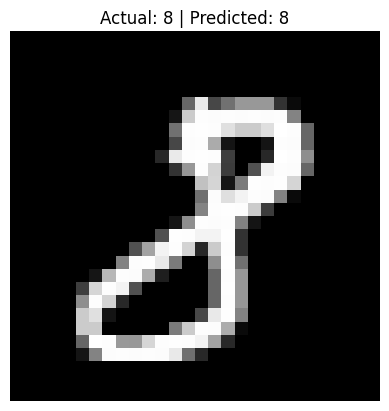

In [23]:
# Pick a random image from the test dataset
index = random.randint(0, len(test_data) - 1)
image, label = test_data[index]

# Prepare the image for the model
input_tensor = image.unsqueeze(0).to(device)

# Predict
model.eval()
with torch.no_grad():
    prediction, _ = model(input_tensor)
    predicted_label = torch.argmax(prediction, 1).item()

# Visualize
plt.imshow((image.squeeze() * std + mean), cmap='gray')
plt.title(f'Actual: {label} | Predicted: {predicted_label}')
plt.axis('off')
plt.show()

Conv2 filters shape: torch.Size([16, 6, 5, 5])


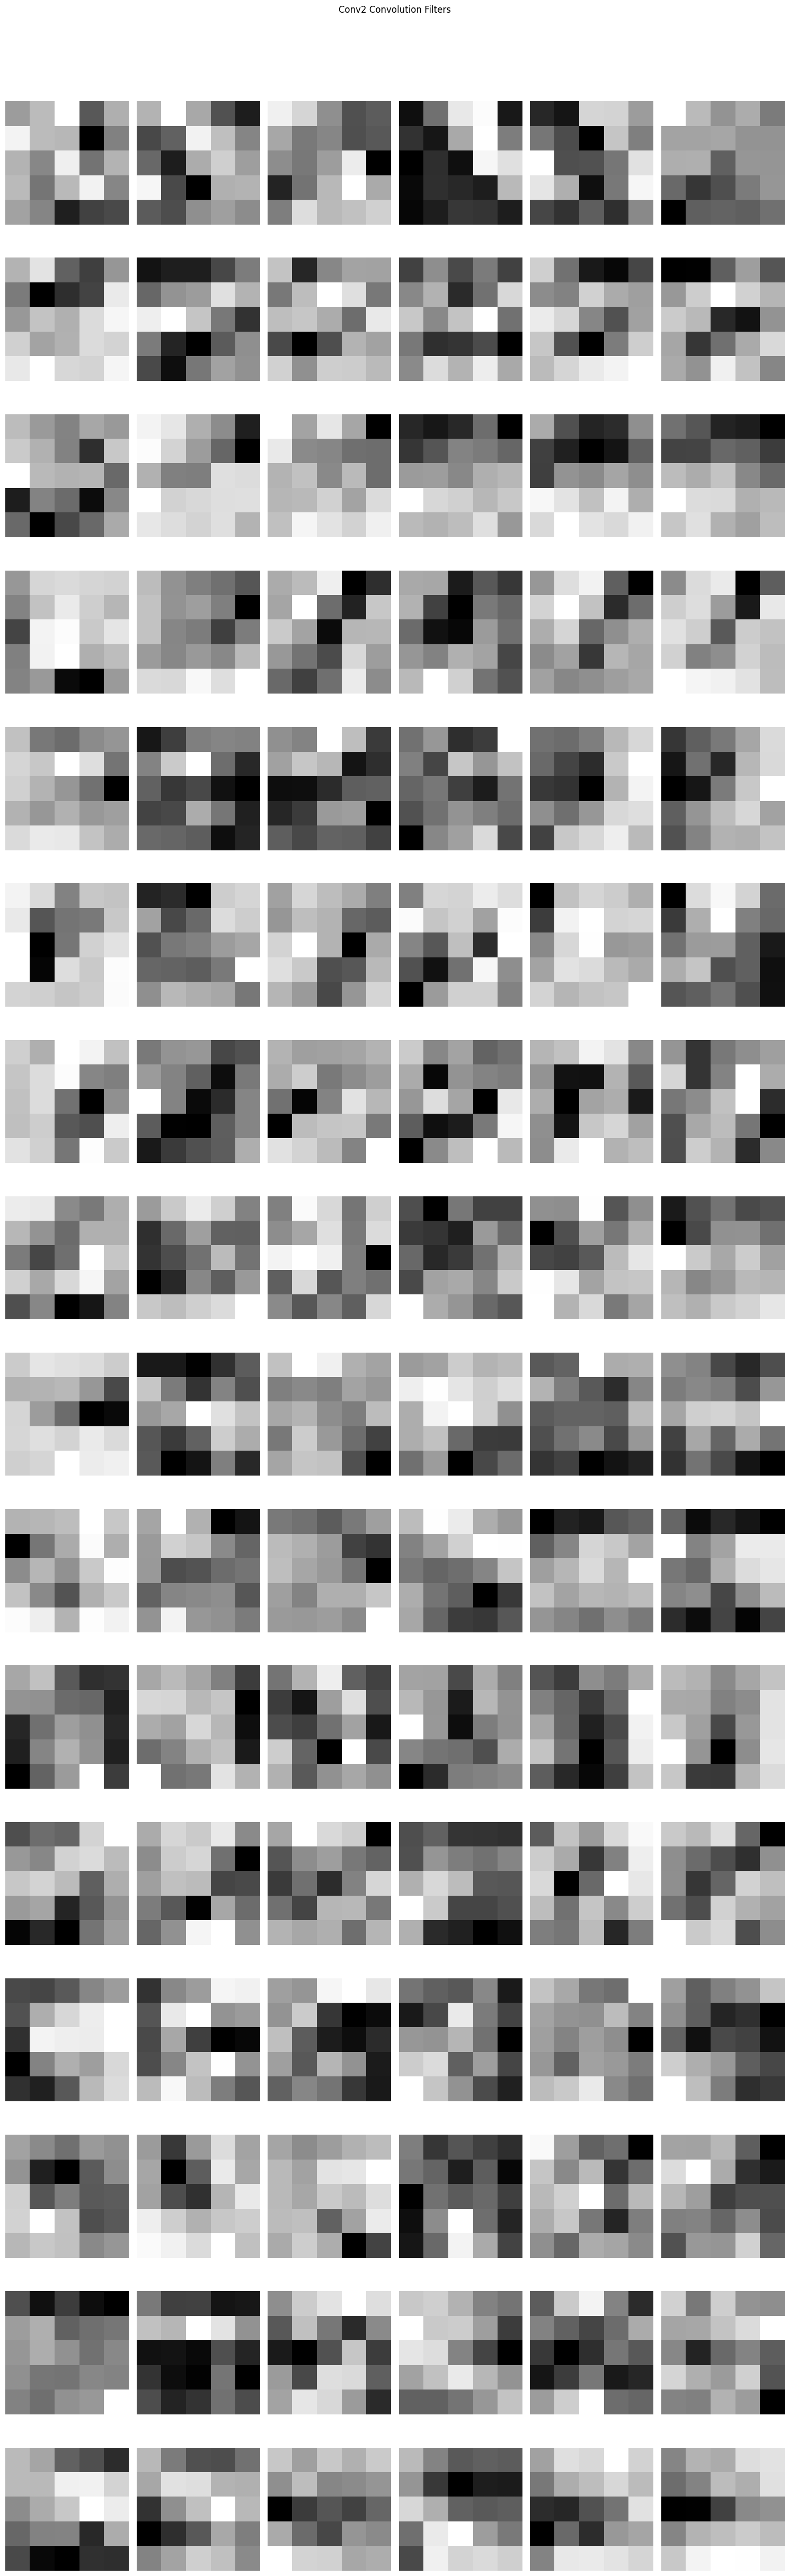

In [38]:
def plot_filters(filters, n_filters, layer_name):
    """Plot individual filter weights for a convolutional layer."""
    fig, axes = plt.subplots(n_filters, filters.shape[1], figsize=(15, 3*n_filters))

    # Handle case when n_filters is 1
    if n_filters == 1:
        axes = [axes]

    for i in range(n_filters):
        for j in range(filters.shape[1]):
            filter_weights = filters[i, j, :, :].detach().cpu().numpy()
            axes[i, j].imshow(filter_weights, cmap='gray')
            axes[i, j].axis('off')

    plt.suptitle(f'{layer_name} Convolution Filters', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()
# Visualize Conv2 filters (16 filters, each with 1 input channel)
model.eval()
with torch.no_grad():
    conv2_weights = model.conv2.weight.detach().cpu()

print(f'Conv2 filters shape: {conv2_weights.shape}')
plot_filters(conv2_weights, n_filters=16, layer_name='Conv2')

Conv1 filters shape: torch.Size([6, 1, 5, 5])


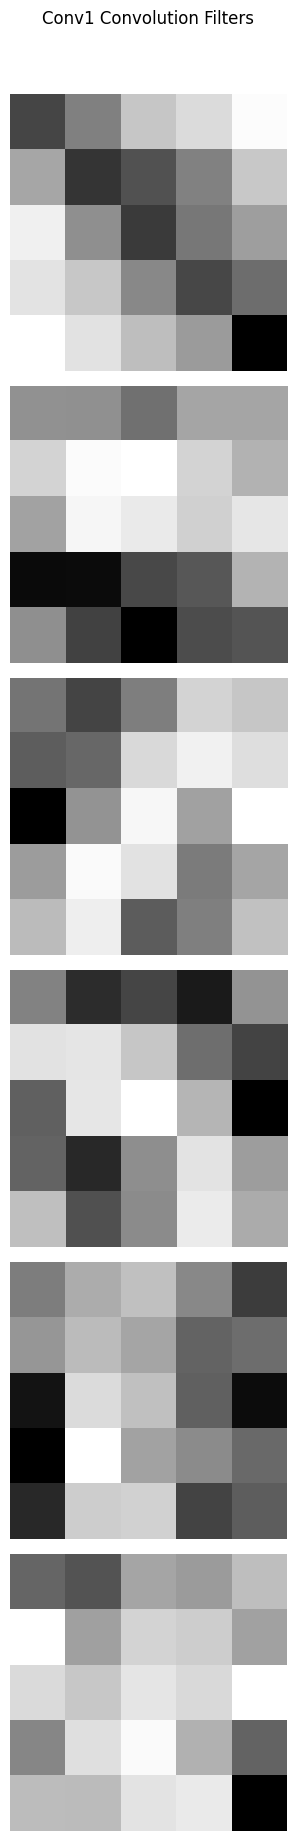

In [28]:
# Visualize Conv1 filters (6 filters, each with 1 input channel)
model.eval()
with torch.no_grad():
    conv1_weights = model.conv1.weight.detach().cpu()

print(f'Conv1 filters shape: {conv1_weights.shape}')
plot_filters(conv1_weights, n_filters=6, layer_name='Conv1')




Conv1 feature maps shape: torch.Size([1, 6, 24, 24])
Conv2 feature maps shape: torch.Size([1, 16, 8, 8])



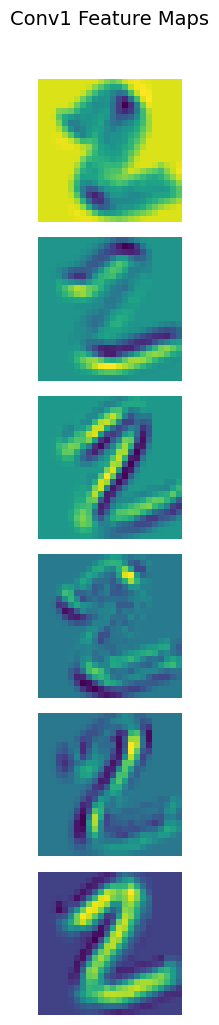

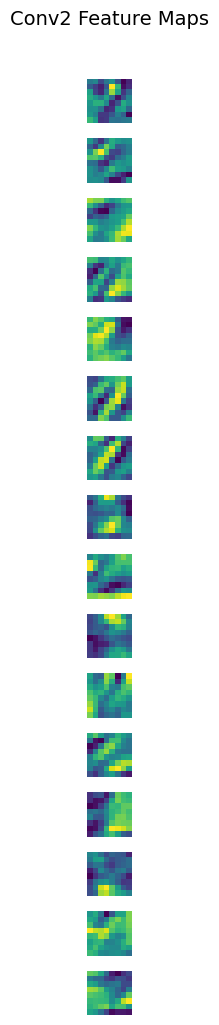

In [44]:
def plot_feature_map(feature_map, title="Feature Map"):
    """Plot a feature map from a convolutional layer."""
    fig, axes = plt.subplots(feature_map.shape[0],  figsize=(10, 10))

    # Handle case when feature_map has only one dimension
    if feature_map.shape[0] == 1:
        axes = [axes]

    for i in range(feature_map.shape[0]):
            axes[i].imshow(feature_map[i], cmap='viridis')
            axes[i].axis('off')

    plt.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Pick a random image from the test dataset
index = random.randint(0, len(test_data) - 1)
image, label = test_data[index]

# Prepare the image for the model
input_tensor = image.unsqueeze(0).to(device)

# Predict and get intermediate features
model.eval()
with torch.no_grad():
    # Get output from both conv layers
    conv1_output = model.conv1(input_tensor)
    x = F.max_pool2d(conv1_output, kernel_size=2)
    x = F.relu(x)
    # Extract feature maps from Conv1 (before max pool)
    conv2_output = model.conv2(x)
    
    print(f'Conv1 feature maps shape: {conv1_output.shape}')
    print(f'Conv2 feature maps shape: {conv2_output.shape}')
    
    # Visualize Conv1 feature maps
    print()
    plot_feature_map(conv1_output[0], title='Conv1 Feature Maps')
    
    # Visualize Conv2 feature maps
    print()
    plot_feature_map(conv2_output[0], title='Conv2 Feature Maps')
